# Microproyecto 2 — Clasificación automática de textos según los Objetivos de Desarrollo Sostenible (ODS)

**Maestría en Inteligencia Artificial — Aprendizaje No Supervisado**  
**Autores:** David Cardenas y Mario Celis  
**Fecha:** septiembre de 2026

---


## 1. Configuración del entorno y carga de datos

### 1.0 Librerías y configuración general

Se fija una semilla aleatoria (`RANDOM_STATE = 42`) para garantizar la reproducibilidad de particiones, modelos y cualquier proceso estocástico a lo largo de todo el notebook.

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import StratifiedGroupKFold

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100

print("Entorno configurado correctamente. RANDOM_STATE =", RANDOM_STATE)

Entorno configurado correctamente. RANDOM_STATE = 42


Para facilitar la lectura, se añade un estilo CSS que centra horizontalmente todas las tablas (DataFrames) mostradas a lo largo del notebook.

In [2]:
from IPython.display import HTML, display

display(HTML("<style>table { margin-left: auto; margin-right: auto; }</style>"))

### 1.1 Carga del corpus

El enunciado especifica que el proyecto utiliza el **OSDG Community Dataset (OSDG-CD)**, versión 2023, con textos **traducidos al español** mediante DeepL y **aumentados** mediante la API de ChatGPT. Para esta entrega se utiliza el archivo proporcionado para la actividad:

- `data/Datos_textosODS.xlsx`: corpus en **español**, ya traducido y aumentado, con las columnas `textos` (texto) y `ODS` (etiqueta numérica).

Por tanto, `Datos_textosODS.xlsx` es la fuente de datos utilizada en todo el desarrollo. El OSDG-CD original se conserva como referencia de procedencia según el enunciado, pero no es necesario incluir una copia adicional del CSV original en el entregable.

In [3]:
DATA_PATH = "data/Datos_textosODS.xlsx"

df = pd.read_excel(DATA_PATH)
df = df.rename(columns={"textos": "text", "ODS": "sdg"})
df["sdg"] = df["sdg"].astype(int)

print("Dimensiones del dataset:", df.shape)
df.info()
df.head(3)

Dimensiones del dataset: (9656, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9656 entries, 0 to 9655
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9656 non-null   object
 1   sdg     9656 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 151.0+ KB


,text,sdg
0,"""Aprendizaje"" y ""educación"" se consideran sinónimos de escolarización formal. Las organizaciones auxiliares, como la...",4
1,No dejar clara la naturaleza de estos riesgos puede dar lugar a un exceso de inversión en empresas dependientes del ...,6
2,"Como resultado, un mayor y mejorado acceso al agua puede afectar aún más la capacidad de adaptación y resiliencia de...",13


In [4]:
sdg_values = sorted(df["sdg"].unique())
missing = sorted(set(range(1, 18)) - set(sdg_values))

print("ODS presentes en el dataset:", sdg_values)
print("Número de clases distintas:", len(sdg_values))
print("ODS ausentes en el corpus:", missing if missing else "ninguno")

ODS presentes en el dataset: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]
Número de clases distintas: 16
ODS ausentes en el corpus: [17]


**Hallazgo:** el corpus suministrado para esta actividad cubre 16 de los 17 ODS y no contiene ejemplos etiquetados como ODS 17 (*Alianzas para lograr los objetivos*). Por tanto, esta ausencia se trata como una **limitación del conjunto de datos disponible**: el clasificador desarrollado en este microproyecto no puede aprender ni predecir una clase que no está representada durante el entrenamiento. No se infiere una causa adicional para esta ausencia porque los archivos proporcionados no permiten demostrarla.


### 1.2 Calidad de los datos

Se revisan nulos, textos vacíos, longitud mínima y duplicados **exactos** (comparando el texto tal cual y también una versión normalizada en minúsculas/sin puntuación, que detecta duplicados que solo difieren en mayúsculas o espacios).

In [5]:
def normalize_text(s):
    s = str(s).lower().strip()
    s = re.sub(r"[^\w\sáéíóúñü]", " ", s, flags=re.UNICODE)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["text_norm"] = df["text"].apply(normalize_text)
df["n_words"] = df["text"].astype(str).str.split().str.len()

n_nulls = df["text"].isna().sum()
n_empty = (df["text_norm"] == "").sum()
n_dup_exact = df.duplicated(subset=["text"]).sum()
n_dup_norm = df.duplicated(subset=["text_norm"]).sum()
n_very_short = (df["n_words"] < 5).sum()

print(f"Textos nulos: {n_nulls} | Textos vacíos: {n_empty}")
print(f"Duplicados exactos (texto tal cual): {n_dup_exact}")
print(f"Duplicados tras normalizar (minúsculas/puntuación/espacios): {n_dup_norm}")
print(f"Textos con menos de 5 palabras: {n_very_short}")
df["n_words"].describe()

Textos nulos: 0 | Textos vacíos: 0
Duplicados exactos (texto tal cual): 0
Duplicados tras normalizar (minúsculas/puntuación/espacios): 0
Textos con menos de 5 palabras: 0


count    9656.000000
mean      111.017295
std        37.082212
min        24.000000
25%        82.000000
50%       105.000000
75%       135.000000
max       268.000000
Name: n_words, dtype: float64

### 1.3 Detección de casi-duplicados (riesgo de fuga de información)

El enunciado indica que el corpus fue **aumentado mediante la API de ChatGPT**. Es una práctica común de aumentación generar **paráfrasis** del mismo texto original; si dos paráfrasis del mismo texto terminan una en entrenamiento y otra en prueba, se produce **fuga de información** (el modelo vería en evaluación una variante casi idéntica de algo que ya aprendió), lo que sobreestimaría su desempeño real.

**Enfoque:** en lugar de eliminar estos textos (lo que perdería información útil), se agrupan los textos idénticos o casi idénticos en un mismo *grupo*, y en la sección 1.7 se garantiza —mediante una partición agrupada (`StratifiedGroupKFold`)— que **todo un grupo caiga íntegramente en un único conjunto** (entrenamiento o prueba). Así se elimina el riesgo de fuga sin descartar datos.

**Método:**
1. Se vectorizan los textos normalizados con TF-IDF (vocabulario acotado a 5000 términos).
2. Se calculan, para cada texto, sus vecinos más cercanos por similitud coseno.
3. Se consideran "casi-duplicados" los pares con similitud ≥ 0.90.
4. Se agrupan (unión de conjuntos disjuntos) los textos idénticos tras normalizar **y** los casi-duplicados detectados.

In [6]:
tfidf_dedup = TfidfVectorizer(max_features=5000, min_df=2)
X_dedup = tfidf_dedup.fit_transform(df["text_norm"])

N_NEIGHBORS = 6
SIM_THRESHOLD = 0.90

nn = NearestNeighbors(n_neighbors=N_NEIGHBORS, metric="cosine", algorithm="brute")
nn.fit(X_dedup)
distances, neighbor_idx = nn.kneighbors(X_dedup)

n = len(df)
near_dup_pairs = []
for i in range(n):
    for pos in range(1, N_NEIGHBORS):
        j = neighbor_idx[i, pos]
        sim = 1 - distances[i, pos]
        if sim >= SIM_THRESHOLD and j > i:
            near_dup_pairs.append((i, j, sim))

print(f"Pares casi-duplicados detectados (similitud coseno >= {SIM_THRESHOLD}): {len(near_dup_pairs)}")
if near_dup_pairs:
    ejemplo_i, ejemplo_j, ejemplo_sim = max(near_dup_pairs, key=lambda t: t[2])
    print(f"\nEjemplo de par casi-duplicado (similitud={ejemplo_sim:.3f}):")
    print("Texto A:", df.loc[ejemplo_i, "text"][:200], "...")
    print("Texto B:", df.loc[ejemplo_j, "text"][:200], "...")

Pares casi-duplicados detectados (similitud coseno >= 0.9): 4

Ejemplo de par casi-duplicado (similitud=0.915):
Texto A: El CCXG (anteriormente llamado Grupo de Expertos del Anexo I) es un grupo de delegados gubernamentales de la OCDE y otros países industrializados. El objetivo del grupo es promover el diálogo y mejora ...
Texto B: El CCXG (anteriormente llamado Grupo de Expertos del Anexo I) es un grupo de delegados gubernamentales de la OCDE y otros países industrializados. El objetivo del grupo es promover el diálogo y mejora ...


In [7]:
parent = list(range(n))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(x, y):
    rx, ry = find(x), find(y)
    if rx != ry:
        parent[ry] = rx

for _, idxs in df.groupby("text_norm").groups.items():
    idxs = list(idxs)
    for k in range(1, len(idxs)):
        union(idxs[0], idxs[k])

for i, j, _ in near_dup_pairs:
    union(i, j)

df["group_id"] = [find(i) for i in range(n)]

n_groups = df["group_id"].nunique()
group_sizes = df["group_id"].value_counts()

print(f"Filas totales: {n} | Grupos únicos tras agrupar duplicados/casi-duplicados: {n_groups}")
print(f"Textos que pertenecen a un grupo de tamaño > 1: {(group_sizes[df['group_id'].map(group_sizes)] > 1).sum() if False else (df['group_id'].map(group_sizes) > 1).sum()}")
print("\nTamaño de los 5 grupos más grandes:")
print(group_sizes.head())

label_nunique_per_group = df.groupby("group_id")["sdg"].nunique()
n_label_conflicts = (label_nunique_per_group > 1).sum()
print(f"\nGrupos de (casi-)duplicados con etiquetas ODS distintas entre sí: {n_label_conflicts}")

Filas totales: 9656 | Grupos únicos tras agrupar duplicados/casi-duplicados: 9652
Textos que pertenecen a un grupo de tamaño > 1: 7

Tamaño de los 5 grupos más grandes:
group_id
3232    3
406     2
803     2
6436    1
6437    1
Name: count, dtype: int64

Grupos de (casi-)duplicados con etiquetas ODS distintas entre sí: 0


### 1.4 Distribución de clases (ODS)

Se examina el balance de clases, ya que un fuerte desbalance entre ODS puede sesgar tanto el modelo de clasificación como la elección de las métricas de evaluación (secciones 4 y 5).

,n_textos,porcentaje
sdg,,
1,505,5.23
2,369,3.82
3,894,9.26
4,1025,10.62
5,1070,11.08
6,695,7.20
7,787,8.15
8,446,4.62
9,343,3.55


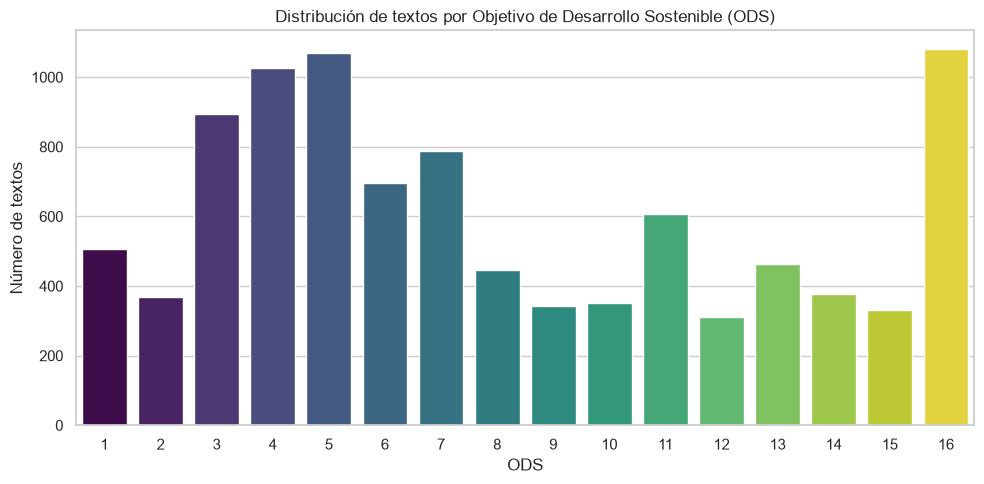

ODS más frecuente: 16 (1080 textos)
ODS menos frecuente: 12 (312 textos)
Razón desbalance (max/min): 3.46


In [8]:
class_counts = df["sdg"].value_counts().sort_index()
class_pct = (class_counts / class_counts.sum() * 100).round(2)

summary_classes = pd.DataFrame({"n_textos": class_counts, "porcentaje": class_pct})
display(summary_classes)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, ax=ax, palette="viridis", legend=False)
ax.set_xlabel("ODS")
ax.set_ylabel("Número de textos")
ax.set_title("Distribución de textos por Objetivo de Desarrollo Sostenible (ODS)")
plt.tight_layout()
plt.show()

print(f"ODS más frecuente: {class_counts.idxmax()} ({class_counts.max()} textos)")
print(f"ODS menos frecuente: {class_counts.idxmin()} ({class_counts.min()} textos)")
print(f"Razón desbalance (max/min): {class_counts.max()/class_counts.min():.2f}")

**Observación:** las clases no están balanceadas — la más grande (ODS 16) tiene poco más de tres veces los ejemplos de la más chica (ODS 12), una razón de 3.46 a 1. No es un desbalance brutal como los que se ven en detección de fraude, donde una clase puede tener cien veces menos ejemplos que otra, pero sí alcanza para que accuracy mienta: un modelo que le acierte bien a las clases grandes y le vaya mal a las chicas puede seguir viéndose bien en el número global. Por eso más adelante se usa F1 macro en vez de accuracy —le da el mismo peso a cada ODS sin importar cuántos textos tenga— y se prueba class_weight="balanced" en el SVM. Lo que no se hizo, a propósito, fue recurrir a algo como SMOTE: sobre un espacio de miles de dimensiones dispersas (o incluso sobre las 20 componentes de LSA), inventar ejemplos sintéticos interpolando vecinos no genera oraciones reales, genera ruido. Ajustar el peso de las clases en la función de costo es la forma más segura de manejar este desbalance sin fabricar datos que no existen.

### 1.5 Distribución de la longitud de los textos

Se analiza la longitud de los textos (en número de palabras), tanto de forma global como por ODS, para entender la naturaleza del corpus antes de vectorizarlo.

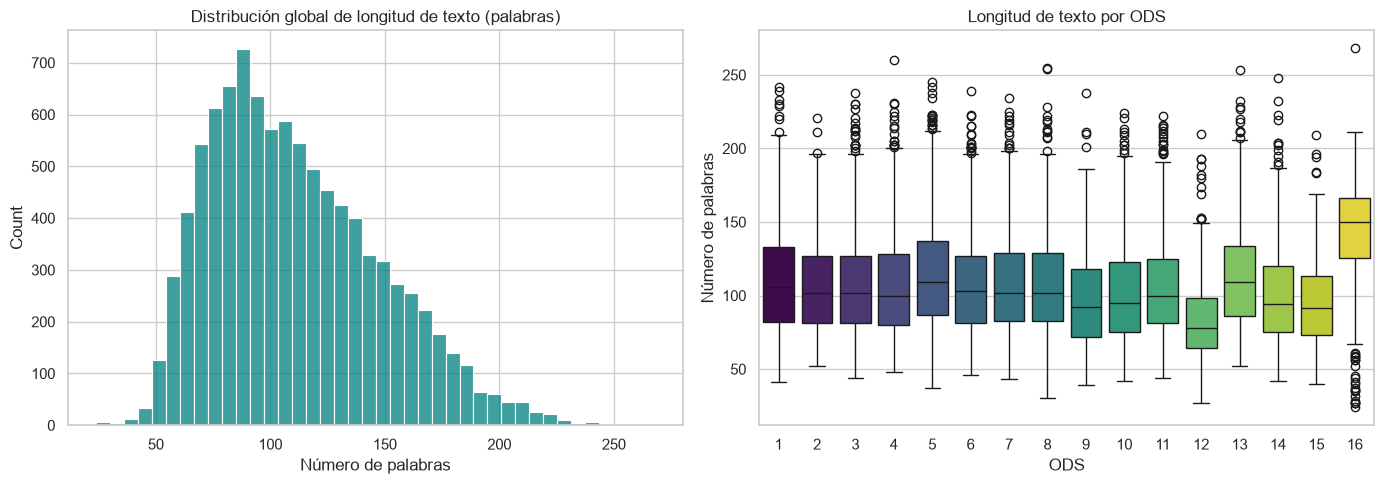

count    9656.000000
mean      111.017295
std        37.082212
min        24.000000
25%        82.000000
50%       105.000000
75%       135.000000
max       268.000000
Name: n_words, dtype: float64

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["n_words"], bins=40, ax=axes[0], color="teal")
axes[0].set_title("Distribución global de longitud de texto (palabras)")
axes[0].set_xlabel("Número de palabras")

sns.boxplot(x="sdg", y="n_words", hue="sdg", data=df, ax=axes[1], palette="viridis", legend=False)
axes[1].set_title("Longitud de texto por ODS")
axes[1].set_xlabel("ODS")
axes[1].set_ylabel("Número de palabras")

plt.tight_layout()
plt.show()

df["n_words"].describe()

### 1.6 Exploración textual: vocabulario por ODS y verificación de idioma

Antes de construir formalmente el pipeline TF-IDF (sección 2), conviene explorar el vocabulario del corpus:

- **Términos más frecuentes por ODS** (uni/bi-gramas, excluyendo *stopwords* en español), para verificar que el vocabulario dominante de cada clase sea coherente con el ODS correspondiente.
- **Verificación de residuos de idioma**: como los textos fueron traducidos automáticamente (DeepL), es razonable comprobar que no queden fragmentos sin traducir en inglés.

In [10]:
SPANISH_STOPWORDS = set((
    "de la que el en y a los del se las por un para con no una su al lo como más pero sus le ya o "
    "este si porque esta entre cuando muy sin sobre tambien me hasta hay donde quien desde todo nos "
    "durante todos uno les ni contra otros ese eso ante ellos e esto mi antes algunos que unos yo "
    "otro otras otra el tanto esa estos mucho quienes nada muchos cual poco ella estar estas algunas "
    "algo nosotros mi mis tu te ti tu tus ellas nosotras vosotros vosotras os mio mia mios mias tuyo "
    "tuya tuyos tuyas suyo suya suyos suyas nuestro nuestra nuestros nuestras vuestro vuestra "
    "vuestros vuestras esos esas estoy estas esta estamos estais estan este estes estemos esteis "
    "esten estare estaras estara estaremos estareis estaran estaria estarias estariamos estariais "
    "estarian estaba estabas estabamos estabais estaban soy eres es somos sois son sea seas seamos "
    "seais sean sere seras sera seremos sereis seran seria serias seriamos seriais serian era eras "
    "eramos erais eran fui fuiste fue fuimos fuisteis fueron siendo sido tengo tienes tiene tenemos "
    "teneis tienen haber puede pueden puedo puedes podemos podeis ser hacer tras solo "
    "asimismo asi cada dentro fuera ademas mediante debe deben como cual cuales"
).split())

count_vec = CountVectorizer(
    ngram_range=(1, 2), min_df=5, max_features=3000, stop_words=list(SPANISH_STOPWORDS)
)
X_counts = count_vec.fit_transform(df["text"])
vocab = np.array(count_vec.get_feature_names_out())

top_terms_por_ods = {}
for sdg in sorted(df["sdg"].unique()):
    mask = (df["sdg"] == sdg).values
    freqs = np.asarray(X_counts[mask].sum(axis=0)).ravel()
    top_idx = freqs.argsort()[::-1][:6]
    top_terms_por_ods[sdg] = ", ".join(vocab[top_idx])

tabla_terminos = pd.DataFrame.from_dict(top_terms_por_ods, orient="index", columns=["términos_más_frecuentes"])
tabla_terminos.index.name = "ODS"
tabla_terminos

,términos_más_frecuentes
ODS,
1,"pobreza, países, ingresos, pobres, niños, hogares"
2,"alimentos, producción, alimentaria, precios, países, también"
3,"salud, atención, servicios, países, también, mental"
4,"educación, estudiantes, escuelas, aprendizaje, docentes, evaluación"
5,"mujeres, género, hombres, países, igualdad, trabajo"
6,"agua, aguas, gestión, recursos, también, países"
7,"energía, electricidad, energética, renovables, eficiencia, capacidad"
8,"empleo, trabajo, trabajadores, laboral, países, también"
9,"desarrollo, innovación, países, servicios, infraestructura, también"


**Interpretación:** a simple vista, las palabras que más se repiten en cada ODS tienen sentido con su tema — agua y saneamiento en el ODS 6, clima en el ODS 13. Es una buena señal, pero hay que decirlo con cuidado: es una lectura visual sobre una lista de seis palabras por clase, no una medida. Si se calculara el solapamiento entre los términos top de cada par de ODS (por ejemplo con Jaccard), probablemente saltaría algo que ya se intuye mirando la tabla: el ODS 8 ("empleo, trabajo, trabajadores, laboral") y el ODS 10 ("desigualdad, ingresos... social") comparten bastante vocabulario económico. Y no es casualidad — ese es justo el par que más se confunde más adelante, en la matriz de confusión de la sección 6. Tampoco conviene dejarse engañar por la frecuencia: palabras como "países", "desarrollo" o "también" aparecen en el top de varios ODS a la vez, porque son vocabulario genérico de cualquier texto sobre políticas públicas, no algo específico de un tema. TF-IDF ya las castiga un poco, pero siguen colándose. Ese mismo patrón —un vocabulario compartido de "discurso de desarrollo" que no distingue bien entre ODS— vuelve a aparecer solo, de forma independiente, cuando se interpretan los tópicos de LSA en la sección 3.3.

In [11]:
ENGLISH_FUNCTION_WORDS = set(
    "the and of to in is for that with as by an be this from or are at which but "
    "their have has not will would can could should shall than then into onto over".split()
)

def english_fraction(text):
    words = re.findall(r"[a-záéíóúñü]+", str(text).lower())
    if not words:
        return 0.0
    n_en = sum(1 for w in words if w in ENGLISH_FUNCTION_WORDS)
    return n_en / len(words)

df["frac_en"] = df["text"].apply(english_fraction)
UMBRAL_EN = 0.15
n_sospechosos = (df["frac_en"] > UMBRAL_EN).sum()
print(f"Textos con posibles residuos de inglés sin traducir (>{UMBRAL_EN:.0%} de palabras función en inglés): {n_sospechosos}")

if n_sospechosos > 0:
    display(df.sort_values("frac_en", ascending=False)[["text", "frac_en"]].head(3))
else:
    print("No se detectan indicios relevantes de texto sin traducir.")

Textos con posibles residuos de inglés sin traducir (>15% de palabras función en inglés): 0
No se detectan indicios relevantes de texto sin traducir.


### 1.7 Partición en entrenamiento y prueba (agrupada y estratificada)

**Cambio de diseño respecto a un esquema train/val/test tradicional:** con clases minoritarias de alrededor de 300 textos, reservar además un conjunto de validación fijo reduciría innecesariamente los ejemplos disponibles para ajustar y comparar modelos. En su lugar:

- Se reserva un **conjunto de prueba (test)** de aproximadamente el 20%, que solo se utiliza al final, en la **sección 6**.
- La selección del algoritmo y de los hiperparámetros se realiza mediante **validación cruzada estratificada y agrupada** sobre el conjunto de entrenamiento, en las **secciones 4 y 5**, aprovechando mejor los datos disponibles de las clases minoritarias.

La partición usa `StratifiedGroupKFold`, que busca simultáneamente:
1. Mantener proporciones de clases (ODS) similares entre entrenamiento y prueba.
2. Evitar que un mismo grupo de textos (casi-)duplicados de la sección 1.3 quede repartido entre ambos conjuntos, reduciendo el riesgo de fuga de información.

In [12]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(df["text"], df["sdg"], groups=df["group_id"]))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

X_train, y_train = df_train["text"].values, df_train["sdg"].values
X_test, y_test = df_test["text"].values, df_test["sdg"].values
groups_train = df_train["group_id"].values

print(f"Entrenamiento: {len(X_train)} textos ({len(X_train)/len(df):.1%})")
print(f"Prueba:        {len(X_test)} textos ({len(X_test)/len(df):.1%})")

overlap = set(df_train["group_id"]) & set(df_test["group_id"])
print(f"\nGrupos presentes en ambos conjuntos simultáneamente (debe ser 0): {len(overlap)}")

check = pd.DataFrame({
    "train_%": pd.Series(y_train).value_counts(normalize=True).sort_index() * 100,
    "test_%":  pd.Series(y_test).value_counts(normalize=True).sort_index() * 100,
}).round(2)
check

Entrenamiento: 7725 textos (80.0%)
Prueba:        1931 textos (20.0%)

Grupos presentes en ambos conjuntos simultáneamente (debe ser 0): 0


,train_%,test_%
1,5.23,5.23
2,3.83,3.78
3,9.26,9.27
4,10.61,10.62
5,11.08,11.08
6,7.20,7.20
7,8.14,8.18
8,4.62,4.61
9,3.56,3.52
10,3.65,3.63


**Cierre de la sección 1:** ya queda el corpus caracterizado — calidad de datos revisada, casi-duplicados agrupados para que no se cuelen entre train y test, distribución de clases y de longitud entendida, y una primera mirada al vocabulario por ODS. Un punto para tener presente: la detección de casi-duplicados se hizo con similitud de coseno sobre TF-IDF, que agarra parecido de palabras, no de significado. Si la aumentación con ChatGPT parafraseó fuerte algún texto, es posible que algún casi-duplicado se haya escapado sin que el método lo note. No es grave para este alcance, pero si se quisiera ser más estricto, embeddings de oraciones capturarían esos casos que TF-IDF no ve. Con esto resuelto, toca armar el pipeline de limpieza de texto y vectorización TF-IDF de la sección 2.

## 2. Preparación de texto y pipeline BOW + TF-IDF (Actividad 1)

### 2.1 Estrategia de limpieza y normalización

Decisiones de diseño para esta sección (sin dependencias externas más allá de las ya instaladas — no se usan modelos de terceros como spaCy ni se requieren descargas adicionales de corpora):

- **Tokenización por expresión regular** (letras con o sin tilde), en vez de un tokenizador que dependa de recursos descargables (p. ej. `nltk.word_tokenize` requiere el paquete `punkt`).
- **Se conservan las tildes**: son semánticamente relevantes en español (p. ej. "más" vs. "mas") y el stemmer de Snowball para español está diseñado para operar sobre palabras acentuadas.
- **Normalización morfológica mediante *stemming*** con `SnowballStemmer("spanish")` de NLTK — es determinista, no requiere descargar modelos (a diferencia de la lematización con spaCy) y reduce variantes flexivas (plurales, conjugaciones) a una raíz común, disminuyendo la dimensionalidad del vocabulario.
- **Lista de stopwords ampliada**: se parte de la lista usada en la sección 1.6 y se añaden términos que, aunque frecuentes, resultaron poco discriminativos entre ODS en esa misma exploración (p. ej. "país", "países", "según", "hacia" aparecían como término top en casi todas las clases).

In [13]:
import sys
sys.path.insert(0, "word_predicto_app")

from sklearn.pipeline import Pipeline
from text_pipeline import SpanishTextCleaner, STOPWORDS_ES, STOPWORDS_ES_NORM


print("Clase SpanishTextCleaner importada desde text_pipeline.py. Tamaño de la lista de stopwords:", len(STOPWORDS_ES))

Clase SpanishTextCleaner importada desde text_pipeline.py. Tamaño de la lista de stopwords: 223


### 2.2 Construcción del pipeline TF-IDF

Hiperparámetros elegidos para `TfidfVectorizer` y su justificación:

- `ngram_range=(1, 2)`: se incluyen bigramas además de unigramas, ya que en la sección 1.6 se observó que expresiones como *"cambio climático"* o *"derechos humanos"* son más informativas como unidad que sus palabras por separado.
- `min_df=5`: se descartan términos que aparecen en menos de 5 documentos (probable ruido o errores de traducción aislados).
- `max_df=0.90`: se descartan términos presentes en más del 90% de los documentos (aportan poca capacidad discriminativa).
- `sublinear_tf=True`: aplica escala logarítmica a la frecuencia de término (`1 + log(tf)`), práctica estándar en clasificación de texto para atenuar el efecto de palabras que se repiten muchas veces dentro de un mismo documento.

Se usa **TF-IDF y no conteos crudos (BOW simple)** porque des-pondera automáticamente los términos frecuentes en todo el corpus (poco discriminativos) y resalta los específicos de cada documento/clase — justamente lo que pide la Actividad 1 del enunciado.

**Importante:** el pipeline se ajusta (`fit`) únicamente sobre `X_train`; `X_test` solo se transforma, para no filtrar información del conjunto de prueba hacia el vocabulario o los pesos IDF.

In [14]:
tfidf_pipeline = Pipeline([
    ("cleaner", SpanishTextCleaner(stopwords=STOPWORDS_ES_NORM, use_stemming=True)),
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.90, sublinear_tf=True)),
])

X_train_tfidf = tfidf_pipeline.fit_transform(X_train)
X_test_tfidf = tfidf_pipeline.transform(X_test)

print("Matriz TF-IDF de entrenamiento:", X_train_tfidf.shape)
print("Matriz TF-IDF de prueba:", X_test_tfidf.shape)

sparsity = 1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
print(f"Dispersión (sparsity) de la matriz de entrenamiento: {sparsity:.4%}")

Matriz TF-IDF de entrenamiento: (7725, 13014)
Matriz TF-IDF de prueba: (1931, 13014)
Dispersión (sparsity) de la matriz de entrenamiento: 99.5885%


### 2.3 Inspección del vocabulario resultante

Se revisan los términos con menor y mayor IDF (los primeros son comunes en todo el corpus a pesar del filtro de stopwords; los segundos son específicos de pocos documentos) como control de calidad del vectorizador.

In [15]:
vectorizer = tfidf_pipeline.named_steps["tfidf"]
vocab = vectorizer.get_feature_names_out()
idf = vectorizer.idf_

idf_df = pd.DataFrame({"termino": vocab, "idf": idf}).sort_values("idf")

print(f"Tamaño del vocabulario: {len(vocab)}")
print("\nTérminos más comunes en el corpus (IDF más bajo):")
display(idf_df.head(10))
print("\nTérminos más raros/específicos (IDF más alto):")
display(idf_df.tail(10))

Tamaño del vocabulario: 13014

Términos más comunes en el corpus (IDF más bajo):


,termino,idf
3237,desarroll,2.396441
9496,polit,2.535968
7481,mayor,2.548676
7704,mejor,2.673028
999,aument,2.703842
8381,nivel,2.717448
6289,inclu,2.814274
11630,sistem,2.837577
3848,econom,2.853145
5821,han,2.861437



Términos más raros/específicos (IDF más alto):


,termino,idf
2449,constru sistem,8.160587
8488,non,8.160587
2445,constitut,8.160587
4896,evalu nivel,8.160587
8485,nombramient,8.160587
10804,reiter,8.160587
4897,evalu nuev,8.160587
10806,reivindic,8.160587
10775,region nordic,8.160587
0,aarhus,8.160587


**Cierre de la sección 2:** el pipeline de scikit-learn (`SpanishTextCleaner` + `TfidfVectorizer`) quedó ajustado únicamente con el conjunto de entrenamiento, con cada hiperparámetro justificado, y las matrices `X_train_tfidf` y `X_test_tfidf` listas. El vocabulario resultante tiene **13.014 términos** para **7.725 textos de entrenamiento**, por lo que la representación es de alta dimensionalidad y muy dispersa. Esto justifica aplicar reducción de dimensionalidad mediante LSA antes de la etapa de clasificación, tal como solicita el proyecto.

## 3. Modelo de tópicos LSA mediante `TruncatedSVD` (Actividad 2)

### 3.1 Exploración del número de componentes

Se ajusta `TruncatedSVD` con 20 componentes (el extremo superior del rango sugerido por el enunciado) sobre `X_train_tfidf`. Dentro de este ajuste, las componentes quedan ordenadas por la cantidad de variación capturada, lo que permite inspeccionar la varianza explicada acumulada desde 1 hasta 20 componentes y observar si aparece un punto de rendimientos decrecientes. Esta exploración es descriptiva; la dimensionalidad empleada finalmente por el clasificador se valida posteriormente mediante `GridSearchCV`.

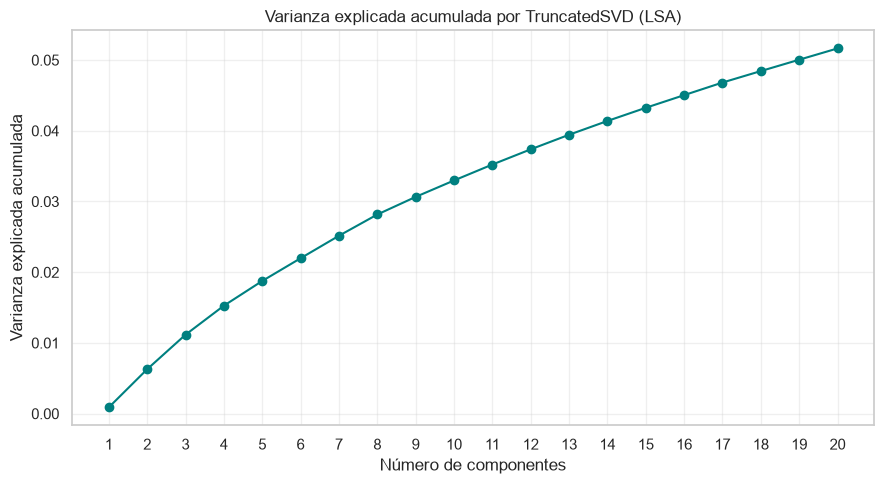

Varianza explicada acumulada para valores clave dentro del rango sugerido (10-20):
  Componentes: 10 -> Varianza explicada acumulada: 0.0330
  Componentes: 12 -> Varianza explicada acumulada: 0.0374
  Componentes: 14 -> Varianza explicada acumulada: 0.0414
  Componentes: 16 -> Varianza explicada acumulada: 0.0450
  Componentes: 18 -> Varianza explicada acumulada: 0.0484
  Componentes: 20 -> Varianza explicada acumulada: 0.0516

Ganancia marginal por componente adicional (últimos tramos):
  10 -> 11 componentes: +0.0023
  11 -> 12 componentes: +0.0021
  12 -> 13 componentes: +0.0021
  13 -> 14 componentes: +0.0019
  14 -> 15 componentes: +0.0019
  15 -> 16 componentes: +0.0018
  16 -> 17 componentes: +0.0018
  17 -> 18 componentes: +0.0016
  18 -> 19 componentes: +0.0016
  19 -> 20 componentes: +0.0016


In [16]:
from sklearn.decomposition import TruncatedSVD

MAX_COMPONENTS = 20
svd_explorer = TruncatedSVD(n_components=MAX_COMPONENTS, random_state=RANDOM_STATE)
svd_explorer.fit(X_train_tfidf)

explained = svd_explorer.explained_variance_ratio_
cum_explained = np.cumsum(explained)
comp_range = np.arange(1, MAX_COMPONENTS + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(comp_range, cum_explained, marker="o", color="teal")
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Varianza explicada acumulada")
ax.set_title("Varianza explicada acumulada por TruncatedSVD (LSA)")
ax.set_xticks(comp_range)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Varianza explicada acumulada para valores clave dentro del rango sugerido (10-20):")
for k in [10, 12, 14, 16, 18, 20]:
    print(f"  Componentes: {k:2d} -> Varianza explicada acumulada: {cum_explained[k-1]:.4f}")

print("\nGanancia marginal por componente adicional (últimos tramos):")
for k in range(11, 21):
    print(f"  {k-1:2d} -> {k:2d} componentes: +{cum_explained[k-1]-cum_explained[k-2]:.4f}")

**Lectura de la curva:** la varianza explicada acumulada es baja en términos absolutos —aproximadamente 5% con 20 componentes—, algo esperable al comprimir una representación TF-IDF de más de 13 mil términos a solo 20 dimensiones densas. Más que el valor absoluto, interesa la forma de la curva: entre 10 y 20 componentes no aparece un codo marcado y la ganancia marginal disminuye de manera gradual.

**Decisión para el análisis de tópicos:** se utilizan 20 componentes, el extremo superior del rango sugerido, para conservar la mayor cantidad posible de señal en esta exploración cualitativa. Para la **clasificación**, sin embargo, no se fija esta decisión únicamente por varianza explicada: `n_components` se evalúa posteriormente como hiperparámetro en la **sección 5**, junto con `C` y `class_weight`, utilizando F1 macro como criterio de selección.

In [17]:
N_COMPONENTS_LSA = 20

svd_model = TruncatedSVD(n_components=N_COMPONENTS_LSA, random_state=RANDOM_STATE)
X_train_lsa = svd_model.fit_transform(X_train_tfidf)
X_test_lsa = svd_model.transform(X_test_tfidf)

print("X_train_lsa:", X_train_lsa.shape)
print("X_test_lsa: ", X_test_lsa.shape)
print(f"Varianza explicada total con {N_COMPONENTS_LSA} componentes: {svd_model.explained_variance_ratio_.sum():.4f}")

X_train_lsa: (7725, 20)
X_test_lsa:  (1931, 20)
Varianza explicada total con 20 componentes: 0.0516


### 3.2 Extracción de tópicos

Para cada componente de `TruncatedSVD`, los términos con mayor peso absoluto (positivo o negativo) en el vector de la componente son los que más contribuyen a ese "tópico" latente. Se muestran en detalle los primeros 8 componentes (más de los 5 mínimos requeridos) y, de forma resumida, las 20 en una tabla.

In [18]:
feature_names = np.array(tfidf_pipeline.named_steps["tfidf"].get_feature_names_out())
N_TOPICS_DETALLE = 8
N_TERMS = 10

for comp_idx in range(N_TOPICS_DETALLE):
    loadings = svd_model.components_[comp_idx]
    top_idx = np.argsort(np.abs(loadings))[::-1][:N_TERMS]
    top_terms = [f"{feature_names[i]} ({loadings[i]:+.2f})" for i in top_idx]
    print(f"Tópico {comp_idx + 1}: " + ", ".join(top_terms))

Tópico 1: desarroll (+0.13), polit (+0.12), mayor (+0.10), mejor (+0.10), trabaj (+0.10), aument (+0.09), nivel (+0.09), mujer (+0.09), educ (+0.09), derech (+0.09)
Tópico 2: derech (+0.40), derech human (+0.23), human (+0.22), internacional (+0.21), articul (+0.16), derech internacional (+0.13), energ (-0.12), estad (+0.12), tribunal (+0.11), ley (+0.11)
Tópico 3: mujer (+0.24), agu (-0.21), energ (-0.19), trabaj (+0.19), educ (+0.19), niñ (+0.14), ingres (+0.14), hombr (+0.13), pobrez (+0.13), laboral (+0.12)
Tópico 4: escuel (+0.23), educ (+0.21), estudi (+0.17), pobrez (-0.15), docent (+0.14), derech (-0.14), mujer (-0.14), ingres (-0.14), aprendizaj (+0.13), energ (-0.13)
Tópico 5: salud (+0.30), atencion (+0.27), mujer (-0.20), medic (+0.19), agu (+0.18), servici (+0.16), mental (+0.16), gener (-0.16), pacient (+0.16), energ (-0.15)
Tópico 6: mujer (+0.38), estudi (-0.19), gener (+0.19), escuel (-0.18), hombr (+0.17), salud (+0.16), educ (-0.14), atencion (+0.13), servici (+0.13)

In [19]:
resumen_topicos = []
for comp_idx in range(N_COMPONENTS_LSA):
    loadings = svd_model.components_[comp_idx]
    top_idx = np.argsort(np.abs(loadings))[::-1][:5]
    resumen_topicos.append({
        "topico": comp_idx + 1,
        "terminos_principales": ", ".join(feature_names[top_idx]),
        "varianza_explicada": svd_model.explained_variance_ratio_[comp_idx],
    })

tabla_topicos = pd.DataFrame(resumen_topicos)
tabla_topicos

,topico,terminos_principales,varianza_explicada
0,1,"desarroll, polit, mayor, mejor, trabaj",0.000892
1,2,"derech, derech human, human, internacional, articul",0.005387
2,3,"mujer, agu, energ, trabaj, educ",0.004883
3,4,"escuel, educ, estudi, pobrez, docent",0.004103
4,5,"salud, atencion, mujer, medic, agu",0.003496
5,6,"mujer, estudi, gener, escuel, hombr",0.003213
6,7,"energ, agu, electr, renov, energ renov",0.003179
7,8,"agu, climat, mujer, pobrez, cambi",0.003006
8,9,"climat, urban, cambi climat, cambi, econom",0.002490
9,10,"pobrez, trabaj, gener, emple, energ",0.002323


### 3.3 Interpretación cualitativa de los tópicos frente a los ODS

Varios de los tópicos que salen de LSA se pueden leer con bastante claridad:

- El tópico 2 (`derech`, `derech human`, `internacional`, `articul`, `ley`) es puro vocabulario jurídico — encaja directo con el **ODS 16**.
- El tópico 4 (`escuel`, `educ`, `estudi`, `docent`, `aprendizaj`) es educación, **ODS 4**.
- El tópico 5 (`salud`, `atencion`, `medic`, `pacient`, `mental`) es salud, **ODS 3**.
- Los tópicos 7 y 8 contrastan agua (signo positivo) contra energía/renovables y clima (signo negativo) — son ejes bipolares: LSA está detectando que esos temas casi no coexisten en un mismo texto, lo cual tiene sentido porque manejan vocabulario técnico bastante distinto entre sí (**ODS 6** vs. **ODS 7**/**13**).
- El tópico 9 (`climat`, `cambi climat`, `urban`) apunta a **ODS 13**, con algo de mezcla con ODS 11.

Ojo con un detalle técnico antes de sacar conclusiones muy firmes: el signo de cada componente de `TruncatedSVD` es arbitrario, puede cambiar si se reentrena con otra semilla o incluso con otra versión de scikit-learn. Estas lecturas de "eje bipolar" son válidas para este modelo puntual, entrenado con `random_state=42`, pero no hay que tratarlas como una propiedad fija del fenómeno.

El tópico 1 (`desarroll`, `polit`, `mayor`, `mejor`, `trabaj`, `mujer`, `public`), en cambio, no se pega a ningún ODS en particular — agrupa vocabulario genérico de "discurso de desarrollo" que aparece en casi todos los textos. Esto no es raro: es un patrón bien conocido en LSA sobre texto, donde la primera componente suele capturar la variación compartida entre documentos antes que las diferencias específicas entre clases.

En conjunto, estas componentes son compatibles con parte del vocabulario temático observado en la sección 1.6; su utilidad predictiva se evalúa mediante validación cruzada en la sección 4 — la base para el modelo de clasificación de la sección 4.

### 3.4 Visualización: proyección 2D de los documentos

Se proyectan los documentos de entrenamiento sobre las dos primeras componentes de LSA, coloreados por ODS, como verificación visual adicional de separabilidad (complementaria a la interpretación de tópicos anterior).

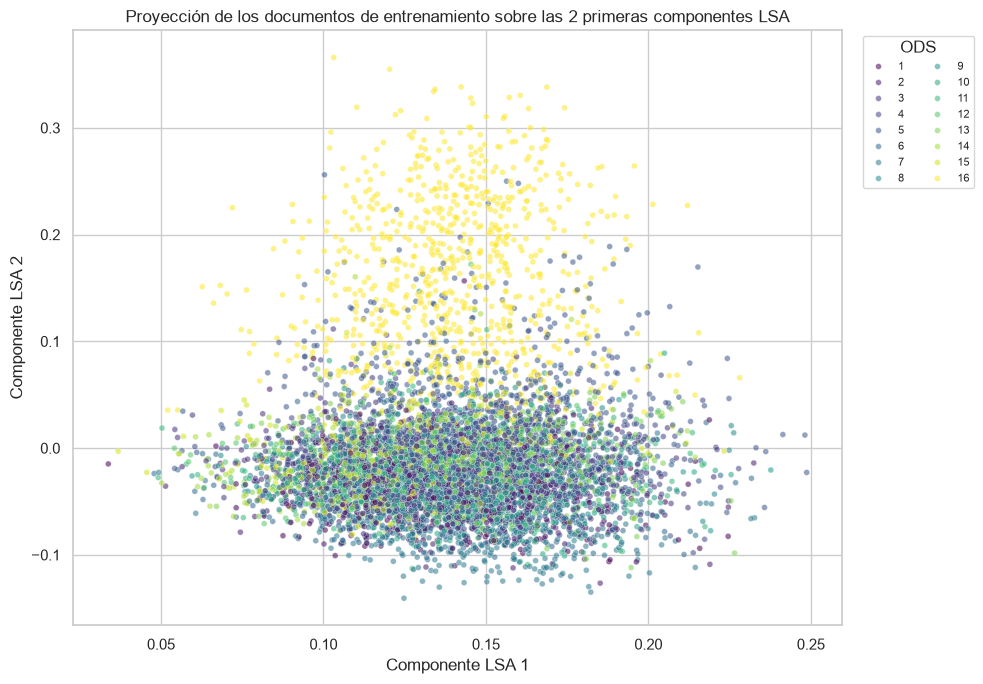

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = sns.scatterplot(
    x=X_train_lsa[:, 0], y=X_train_lsa[:, 1],
    hue=y_train, palette="viridis", s=18, alpha=0.55, ax=ax, legend="full"
)
ax.set_xlabel("Componente LSA 1")
ax.set_ylabel("Componente LSA 2")
ax.set_title("Proyección de los documentos de entrenamiento sobre las 2 primeras componentes LSA")
ax.legend(title="ODS", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

**Lectura del gráfico:** en el plano de las dos primeras componentes no se observan grupos claramente separados por ODS; existe un solapamiento considerable. Esto no implica que las 20 dimensiones LSA carezcan de información discriminativa: una proyección bidimensional descarta la mayor parte de la representación reducida y puede ocultar estructura útil para clasificación. Métodos de visualización no lineal como UMAP o t-SNE podrían utilizarse como análisis exploratorio adicional sobre las 20 componentes, aunque su resultado también dependería de sus hiperparámetros y no sustituiría la evaluación supervisada.

**Cierre de la sección 3:** se obtiene una representación LSA de 20 componentes para el análisis de tópicos, con varios temas interpretables y relacionados cualitativamente con distintos ODS. En la clasificación de las secciones siguientes, la dimensionalidad LSA se vuelve a validar dentro del pipeline para evitar fijarla únicamente a partir de esta exploración.

## 4. Selección de algoritmo (Actividad 3)

### 4.1 Reducción de dimensionalidad dentro del pipeline de clasificación

Para clasificación se mantiene la misma estrategia conceptual de las secciones anteriores —limpieza, TF-IDF y LSA mediante `TruncatedSVD`—, pero se introduce una mejora metodológica importante: **todas las transformaciones se incluyen dentro del pipeline que entra a validación cruzada**.

Esto evita fuga de información entre folds. En cada partición de validación cruzada, la limpieza/TF-IDF y el SVD se ajustan únicamente con los documentos del fold de entrenamiento, y después se aplican al fold de validación. El conjunto de prueba continúa completamente aislado hasta la sección 6.

### 4.2 Preselección de algoritmos candidatos

- **Regresión logística**: baseline lineal fuerte y eficiente para clasificación multiclase.
- **SVM lineal (`LinearSVC`)**: algoritmo muy competitivo para representaciones textuales y espacios reducidos mediante LSA.
- **Random Forest**: alternativa no lineal capaz de capturar interacciones entre componentes latentes.

Se descarta **Naive Bayes multinomial** porque las componentes de LSA pueden asumir valores negativos, mientras que ese algoritmo requiere entradas no negativas.

### 4.3 Benchmark sin fuga de información

Se comparan los tres candidatos mediante validación cruzada **estratificada y agrupada** (`StratifiedGroupKFold`), reutilizando `groups_train` para impedir que textos casi duplicados de un mismo grupo queden en folds distintos. La métrica principal es **F1 macro**, apropiada frente al desbalance documentado en la sección 1.4 porque otorga el mismo peso a cada ODS.


In [21]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate


def construir_pipeline_clasificacion(clasificador, n_components=20):
    """Pipeline completo: limpieza/TF-IDF -> LSA -> clasificador."""
    return Pipeline([
        ("preprocess", clone(tfidf_pipeline)),
        ("svd", TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)),
        ("classifier", clasificador),
    ])

candidatos = {
    "Regresión Logística": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "SVM Lineal (LinearSVC)": LinearSVC(random_state=RANDOM_STATE, max_iter=5000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}

cv_bench = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados_benchmark = []
for nombre, clasificador in candidatos.items():
    pipeline_candidato = construir_pipeline_clasificacion(clasificador, n_components=20)
    scores = cross_validate(
        pipeline_candidato, X_train, y_train,
        cv=cv_bench, groups=groups_train,
        scoring=["f1_macro", "accuracy"],
        n_jobs=-1,
    )
    resultados_benchmark.append({
        "modelo": nombre,
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
        "accuracy_mean": scores["test_accuracy"].mean(),
        "fit_time_mean_seg": scores["fit_time"].mean(),
    })

tabla_benchmark = pd.DataFrame(resultados_benchmark).sort_values("f1_macro_mean", ascending=False)
tabla_benchmark


,modelo,f1_macro_mean,f1_macro_std,accuracy_mean,fit_time_mean_seg
2,Random Forest,0.760423,0.011678,0.812299,4.723879
1,SVM Lineal (LinearSVC),0.754230,0.006095,0.813205,3.347225
0,Regresión Logística,0.735089,0.007736,0.799225,3.350574


### 4.4 Selección final justificada

El benchmark anterior compara los algoritmos bajo exactamente el mismo esquema de preparación y reducción de dimensionalidad, ajustado desde cero dentro de cada fold. **Random Forest obtiene el mayor F1 macro en esta comparación inicial**, mientras que **LinearSVC queda muy cerca y presenta un tiempo medio de ajuste sustancialmente menor**. Dado que el problema parte de una representación textual TF-IDF seguida de LSA y que el objetivo siguiente es realizar una búsqueda controlada de regularización, balance de clases y número de componentes, se selecciona **SVM Lineal (`LinearSVC`)** para la optimización final.

Esta elección no se basa en declarar que SVM sea universalmente superior, sino en el compromiso observado entre desempeño, costo computacional y un espacio de hiperparámetros manejable para una búsqueda exhaustiva. La sección 5 valida si esa elección mejora al ajustar `C`, `class_weight` y `n_components` mediante F1 macro.

## 5. Búsqueda de hiperparámetros y validación (SVM Lineal)

### 5.1 Espacio de búsqueda

La búsqueda se realiza sobre el **pipeline completo** (`preprocess` → `TruncatedSVD` → `LinearSVC`) para que cada fold ajuste sus propias transformaciones y no exista fuga de información durante la validación cruzada.

Se optimizan tres decisiones:

- **`svd__n_components` = [10, 15, 20]**: explora el rango reducido sugerido en el enunciado y convierte la dimensionalidad LSA en una decisión validada, no fija.
- **`classifier__C` = [0.01, 0.1, 1, 10, 100]**: cubre varios órdenes de magnitud de regularización.
- **`classifier__class_weight` = [None, "balanced"]**: evalúa si compensar el desbalance entre ODS mejora el F1 macro.

Se usa `GridSearchCV` con validación cruzada estratificada y agrupada de 5 folds y **F1 macro** como métrica de selección. De este modo, tanto la reducción de dimensionalidad como los hiperparámetros del clasificador se seleccionan exclusivamente con el conjunto de entrenamiento.


In [22]:
from sklearn.model_selection import GridSearchCV

pipeline_svm = construir_pipeline_clasificacion(
    LinearSVC(random_state=RANDOM_STATE, max_iter=5000),
    n_components=20,
)

param_grid = {
    "svd__n_components": [10, 15, 20],
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__class_weight": [None, "balanced"],
}

cv_search = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv_search,
    n_jobs=-1,
    refit=True,
    return_train_score=False,
)

grid_search.fit(X_train, y_train, groups=groups_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print(f"Mejor F1 macro (validación cruzada): {grid_search.best_score_:.4f}")


Mejores hiperparámetros: {'classifier__C': 100, 'classifier__class_weight': 'balanced', 'svd__n_components': 20}
Mejor F1 macro (validación cruzada): 0.7646


In [23]:
cv_results = pd.DataFrame(grid_search.cv_results_)
tabla_grid = cv_results[[
    "param_svd__n_components",
    "param_classifier__C",
    "param_classifier__class_weight",
    "mean_test_score",
    "std_test_score",
]].rename(columns={
    "param_svd__n_components": "n_components",
    "param_classifier__C": "C",
    "param_classifier__class_weight": "class_weight",
    "mean_test_score": "f1_macro_mean",
    "std_test_score": "f1_macro_std",
}).sort_values("f1_macro_mean", ascending=False)

tabla_grid.reset_index(drop=True).head(15)


,n_components,C,class_weight,f1_macro_mean,f1_macro_std
0,20,100.00,balanced,0.764569,0.010810
1,20,10.00,balanced,0.764363,0.010696
2,20,1.00,balanced,0.763275,0.011591
3,20,100.00,None,0.761532,0.007648
4,20,10.00,None,0.761187,0.007615
5,20,0.10,balanced,0.754587,0.012203
6,20,1.00,None,0.754230,0.006095
7,20,0.01,balanced,0.727847,0.015834
8,15,100.00,balanced,0.716824,0.016958
9,15,10.00,balanced,0.715946,0.017003


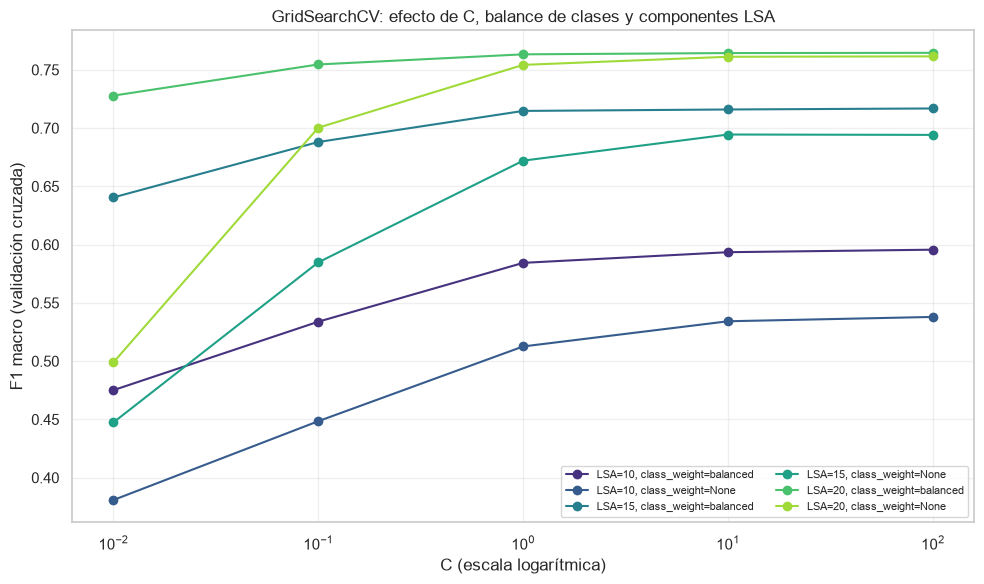

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

for (n_comp, cw), sub in tabla_grid.groupby(["n_components", "class_weight"], dropna=False):
    sub = sub.sort_values("C")
    cw_label = "None" if pd.isna(cw) or cw is None else str(cw)
    ax.plot(
        sub["C"], sub["f1_macro_mean"], marker="o",
        label=f"LSA={int(n_comp)}, class_weight={cw_label}"
    )

ax.set_xscale("log")
ax.set_xlabel("C (escala logarítmica)")
ax.set_ylabel("F1 macro (validación cruzada)")
ax.set_title("GridSearchCV: efecto de C, balance de clases y componentes LSA")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Lectura de la búsqueda:** la tabla y la figura anteriores permiten comparar simultáneamente regularización, ponderación de clases y dimensionalidad LSA. La configuración seleccionada es la que maximiza el **F1 macro medio de validación cruzada**. Al incluir `n_components` en `GridSearchCV`, se cierra explícitamente la decisión que en la sección 3 se había dejado abierta: la dimensionalidad utilizada por el clasificador queda sustentada por validación y no únicamente por la exploración cualitativa de tópicos.

### 5.2 Validación por clase del mejor pipeline

Antes de evaluar el test, se generan predicciones *out-of-fold* sobre entrenamiento utilizando **los mejores hiperparámetros encontrados**, pero volviendo a ajustar el pipeline completo dentro de cada fold. Esto permite inspeccionar precisión, recall y F1 por ODS sin contaminar el conjunto de prueba.


In [25]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

mejor_pipeline_base = clone(grid_search.best_estimator_)

y_train_pred_cv = cross_val_predict(
    mejor_pipeline_base, X_train, y_train,
    cv=cv_search, groups=groups_train, n_jobs=-1,
)

reporte = classification_report(y_train, y_train_pred_cv, output_dict=True, zero_division=0)
tabla_reporte = pd.DataFrame(reporte).T.loc[[str(c) for c in sorted(df["sdg"].unique())]]
tabla_reporte["n_textos_train"] = pd.Series(y_train).value_counts().sort_index().values
tabla_reporte = tabla_reporte.sort_values("f1-score")
tabla_reporte[["precision", "recall", "f1-score", "support", "n_textos_train"]]


,precision,recall,f1-score,support,n_textos_train
9,0.556291,0.610909,0.582322,275.0,275
10,0.613281,0.556738,0.583643,282.0,282
8,0.629393,0.551821,0.588060,357.0,357
12,0.648402,0.568000,0.605544,250.0,250
2,0.643533,0.689189,0.665579,296.0,296
14,0.744094,0.627907,0.681081,301.0,301
15,0.750000,0.761364,0.755639,264.0,264
11,0.782328,0.748454,0.765016,485.0,485
1,0.799499,0.789604,0.794521,404.0,404
13,0.795866,0.830189,0.812665,371.0,371


**Interpretación:** el reporte anterior permite identificar de forma transparente qué ODS son más difíciles para el modelo y evita depender únicamente de una métrica agregada. Las diferencias entre clases pueden relacionarse tanto con el número de ejemplos como con el solapamiento semántico entre categorías (por ejemplo, trabajo, desigualdad, producción o infraestructura). La conclusión se basa en los valores ejecutados de la tabla y no en cifras codificadas manualmente.

### 5.3 Ajuste final sobre todo el conjunto de entrenamiento

`GridSearchCV(refit=True)` vuelve a ajustar automáticamente el mejor pipeline sobre **todo el conjunto de entrenamiento**. Ese objeto será el único utilizado para la evaluación final del test.


In [26]:
modelo_final = grid_search.best_estimator_

print("Modelo final (pipeline completo):")
print(modelo_final)
print()
print("Entrenado sobre:", len(X_train), "textos de entrenamiento")
print("Número de componentes LSA seleccionado:", modelo_final.named_steps["svd"].n_components)


Modelo final (pipeline completo):
Pipeline(steps=[('preprocess',
                 Pipeline(steps=[('cleaner',
                                  SpanishTextCleaner(stopwords={'a', 'ademas',
                                                                'al', 'algo',
                                                                'algunas',
                                                                'algunos',
                                                                'ante', 'antes',
                                                                'asi',
                                                                'asimismo',
                                                                'cada', 'como',
                                                                'con', 'contra',
                                                                'cual',
                                                                'cuales',
                                                

## 6. Evaluación final sobre el conjunto de prueba (Actividad 4)

### 6.1 Predicciones y métricas globales

Se evalúa el **pipeline final completo** sobre `X_test`, un conjunto de textos que permaneció aislado durante selección de algoritmo, reducción de dimensionalidad y búsqueda de hiperparámetros. El propio pipeline aplica limpieza, TF-IDF, SVD y clasificación.

Se reportan:

- **Accuracy**, útil como proporción global de aciertos.
- **F1 macro**, métrica principal porque pondera cada ODS por igual.
- **F1 weighted**, complementaria porque pondera cada clase según su frecuencia.


In [27]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

y_test_pred = modelo_final.predict(X_test)

acc_test = accuracy_score(y_test, y_test_pred)
f1_macro_test = f1_score(y_test, y_test_pred, average="macro")
f1_weighted_test = f1_score(y_test, y_test_pred, average="weighted")

print(f"Accuracy test:    {acc_test:.4f}")
print(f"F1 macro test:    {f1_macro_test:.4f}")
print(f"F1 weighted test: {f1_weighted_test:.4f}")
print(f"Mejor F1 macro CV: {grid_search.best_score_:.4f}")
print(f"Diferencia test - CV: {f1_macro_test - grid_search.best_score_:+.4f}")


Accuracy test:    0.8141
F1 macro test:    0.7677
F1 weighted test: 0.8135
Mejor F1 macro CV: 0.7646
Diferencia test - CV: +0.0032


**Lectura:** la comparación entre el F1 macro de test y el mejor F1 macro de validación cruzada permite detectar una posible brecha de generalización. Una diferencia moderada es esperable porque son estimaciones obtenidas sobre particiones distintas; lo importante es que el test se haya mantenido completamente fuera del proceso de ajuste y selección, como ocurre aquí.


### 6.2 Matriz de confusión

Se visualiza la matriz de confusión sobre las 16 clases presentes, para identificar patrones sistemáticos de error (qué ODS se confunden entre sí).

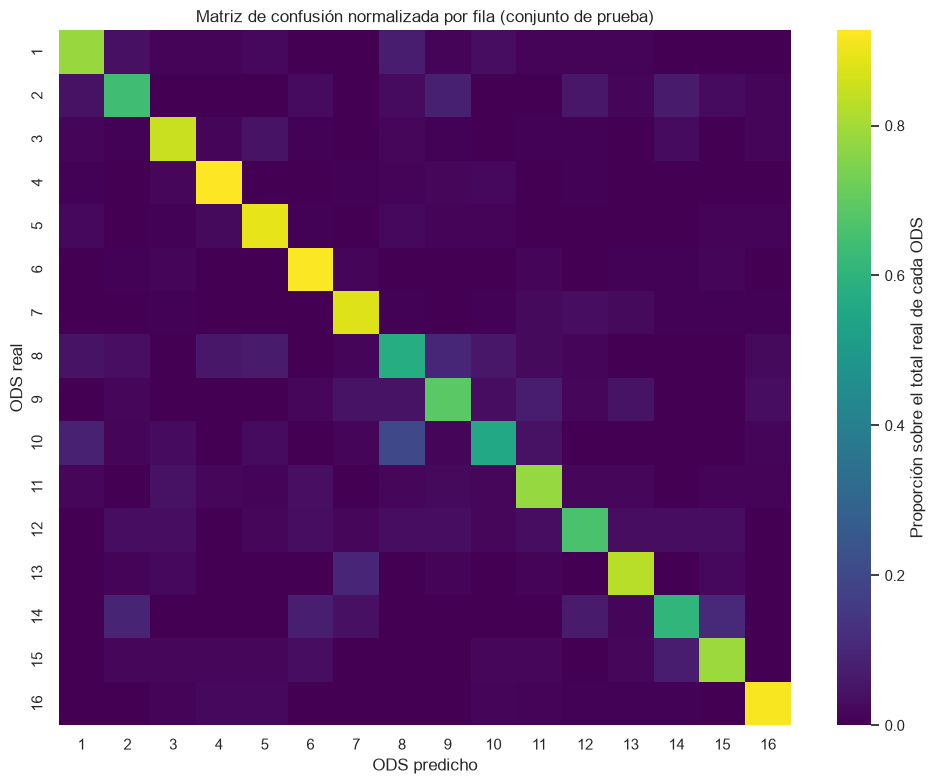

,ods_real,ods_predicho,n_casos
86,10,8,14
67,8,9,9
116,13,7,9
22,3,5,8
125,14,15,8
4,1,8,7
120,14,2,7
81,10,1,6
65,8,5,6
121,14,6,6


In [28]:
etiquetas = sorted(df["sdg"].unique())
cm = confusion_matrix(y_test, y_test_pred, labels=etiquetas)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=False, cmap="viridis", xticklabels=etiquetas, yticklabels=etiquetas, ax=ax,
            cbar_kws={"label": "Proporción sobre el total real de cada ODS"})
ax.set_xlabel("ODS predicho")
ax.set_ylabel("ODS real")
ax.set_title("Matriz de confusión normalizada por fila (conjunto de prueba)")
plt.tight_layout()
plt.show()

pares_confusion = []
for i, real in enumerate(etiquetas):
    for j, pred in enumerate(etiquetas):
        if i != j and cm[i, j] > 0:
            pares_confusion.append((real, pred, cm[i, j]))

tabla_confusion = pd.DataFrame(pares_confusion, columns=["ods_real", "ods_predicho", "n_casos"])
tabla_confusion.sort_values("n_casos", ascending=False).head(10)

La matriz se normaliza por fila —cada celda muestra qué proporción de los casos reales de un ODS terminó en cada predicción—. Con el desbalance observado en la sección 1.4, esta normalización facilita comparar las clases en igualdad de escala.

**Lectura de la matriz de confusión:** la tabla calculada arriba identifica como errores frecuentes ODS 10 → 8, ODS 8 → 9 y ODS 13 → 7. Esos pares son compatibles con posibles solapamientos temáticos (desigualdad y trabajo; trabajo e infraestructura; clima y energía). La matriz describe los errores observados, pero no demuestra su causa ni permite generalizarlos fuera de este corpus.


### 6.3 Reporte de clasificación por ODS

Se compara el desempeño por clase en test contra lo observado en la validación cruzada de la sección 5.2, para ver si los mismos ODS "difíciles" se mantienen.

In [29]:
reporte_test = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
tabla_reporte_test = pd.DataFrame(reporte_test).T.loc[[str(c) for c in etiquetas]]
tabla_reporte_test["n_textos_test"] = pd.Series(y_test).value_counts().sort_index().values
tabla_reporte_test = tabla_reporte_test.sort_values("f1-score")
tabla_reporte_test[["precision", "recall", "f1-score", "support", "n_textos_test"]]

,precision,recall,f1-score,support,n_textos_test
8,0.560440,0.573034,0.566667,89.0,89
10,0.619048,0.557143,0.586466,70.0,70
14,0.696970,0.605263,0.647887,76.0,76
9,0.618421,0.691176,0.652778,68.0,68
12,0.650794,0.661290,0.656000,62.0,62
2,0.681159,0.643836,0.661972,73.0,73
15,0.722222,0.787879,0.753623,66.0,66
1,0.782178,0.782178,0.782178,101.0,101
11,0.798319,0.778689,0.788382,122.0,122
13,0.819149,0.827957,0.823529,93.0,93


**Comparación con la validación cruzada (sección 5.2):** los reportes anteriores muestran que los ODS 8, 9, 10 y 12 siguen entre las clases de menor F1, mientras el ODS 16 mantiene un F1 alto. El reporte *out-of-fold* es descriptivo: los hiperparámetros se eligieron antes usando el mismo conjunto de entrenamiento, por lo que ese reporte no es una estimación independiente adicional. Las métricas finales proceden exclusivamente del test aislado.


### 6.4 Ejemplos concretos de clasificación (conjunto de prueba)

Tal como exige el enunciado, se muestran las clasificaciones del modelo para varios textos del conjunto de prueba: dos aciertos en ODS con buen desempeño, un acierto en un ODS "difícil", y un error real, para ilustrar tanto el comportamiento esperado como sus limitaciones.

In [30]:
df_test_resultados = pd.DataFrame({
    "text": X_test,
    "ods_real": y_test,
    "ods_predicho": y_test_pred,
})
df_test_resultados["acierto"] = df_test_resultados["ods_real"] == df_test_resultados["ods_predicho"]

ejemplos = []

ejemplos.append(df_test_resultados[(df_test_resultados["ods_real"] == 16) & (df_test_resultados["acierto"])].sample(1, random_state=RANDOM_STATE))
ejemplos.append(df_test_resultados[(df_test_resultados["ods_real"] == 4) & (df_test_resultados["acierto"])].sample(1, random_state=RANDOM_STATE))
ejemplos.append(df_test_resultados[(df_test_resultados["ods_real"] == 9) & (df_test_resultados["acierto"])].sample(1, random_state=RANDOM_STATE))
error_10_8 = df_test_resultados[(df_test_resultados["ods_real"] == 10) & (df_test_resultados["ods_predicho"] == 8)]
ejemplos.append(error_10_8.sample(1, random_state=RANDOM_STATE))

ejemplos_df = pd.concat(ejemplos).reset_index(drop=True)

for idx, row in ejemplos_df.iterrows():
    estado = "ACIERTO" if row["acierto"] else "ERROR"
    print(f"--- Ejemplo {idx + 1} [{estado}] | ODS real: {row['ods_real']} | ODS predicho: {row['ods_predicho']} ---")
    print(row["text"][:400] + ("..." if len(row["text"]) > 400 else ""))
    print()

--- Ejemplo 1 [ACIERTO] | ODS real: 16 | ODS predicho: 16 ---
Desarrollamos una historia política de Wards Cove v. Atonio (1989) para mostrar cómo los conceptos de jurisgénesis y jurispatía de Robert Cover pueden enriquecer el marco de movilización legal para comprender el derecho y el cambio social. Ilustramos el valor de la teoría híbrida recuperando la propia comprensión de los trabajadores de Wards Cove sobre el papel del litigio en su lucha por los dere...

--- Ejemplo 2 [ACIERTO] | ODS real: 4 | ODS predicho: 4 ---
Los esfuerzos para cambiar la profesión de liderazgo escolar deben seguir el Marco de Buen Liderazgo Escolar junto con el nuevo Sistema de Formación Docente y Desarrollo Profesional. La provisión de capacitación también debe ser más sistemática y debe depender menos de la capacidad individual de los líderes escolares para acceder a las oportunidades de capacitación. Las universidades y otras insti...

--- Ejemplo 3 [ACIERTO] | ODS real: 9 | ODS predicho: 9 ---
Cuanto m

**Comentario sobre los ejemplos:** se observan tres aciertos —incluido uno en ODS 9— y un error real de ODS 10 clasificado como ODS 8. Este último coincide con el par de confusión más frecuente de la matriz de test y es consistente con posible solapamiento temático, sin demostrar por sí solo la causa del error.

### 6.5 Limitaciones documentadas

- El modelo no puede predecir el **ODS 17**, porque no está representado en el corpus de entrenamiento.
- Persisten diferencias de desempeño entre ODS; las clases 8, 9, 10 y 12 resultan más difíciles que objetivos con vocabulario más distintivo como 4, 6, 7 o 16.
- La evaluación se realizó sobre textos de prueba provenientes del mismo proceso de traducción/aumentación del corpus. El desempeño sobre textos escritos directamente en español y provenientes de otras fuentes puede variar.

**Cierre de la sección 6:** el pipeline final incluye TF-IDF, LSA con `TruncatedSVD` y SVM lineal. Los valores exactos de hiperparámetros, F1 macro, F1 ponderado y accuracy son los impresos por las celdas ejecutadas de las secciones 5 y 6 y exportados en `metrics_summary.json`.


## 7. Conclusiones generales

**Datos.** El corpus suministrado (OSDG-CD en español, 9.656 textos) cubre 16 de los 17 ODS; el ODS 17 no está representado. Se revisaron nulos, vacíos, duplicados y casi-duplicados, y estos últimos se agruparon para evitar contaminación entre entrenamiento y prueba.

**Preparación de texto.** Se construyó un pipeline reproducible con `SpanishTextCleaner` + `TfidfVectorizer`, utilizando unigramas y bigramas, stopwords en español, stemming y ponderación TF-IDF.

**LSA.** El análisis semántico latente mediante `TruncatedSVD` permitió extraer e interpretar al menos cinco tópicos frente a los ODS, cumpliendo el componente no supervisado solicitado. Para clasificación, el número de componentes se incluyó además como hiperparámetro dentro de la validación cruzada.

**Modelo.** Se compararon Regresión Logística, SVM Lineal y Random Forest mediante un pipeline completo ajustado dentro de cada fold. Posteriormente se optimizaron con `GridSearchCV` el número de componentes LSA, `C` y `class_weight` de `LinearSVC`, utilizando F1 macro y validación cruzada estratificada y agrupada.

**Desempeño final.** El resultado definitivo se reporta en la sección 6 sobre un conjunto de prueba completamente aislado. Además de métricas globales, se presentan métricas por ODS, matriz de confusión y al menos cuatro clasificaciones concretas de textos no utilizados durante el aprendizaje, tal como exige el enunciado.

**Limitaciones.** El modelo no puede predecir el ODS 17 porque esa clase no aparece en los datos suministrados. También pueden existir diferencias de desempeño entre ODS semánticamente cercanos y entre los textos traducidos/aumentados del corpus y textos genuinamente nuevos escritos directamente en español.


## 8. Exportación del modelo y aplicación Streamlit (Bonificación opcional)

La aplicación oficial es **Streamlit** (`word_predicto_app/streamlit_app.py`). Carga el pipeline completo evaluado en la sección 6 y una versión calibrada de ese mismo pipeline para mostrar probabilidades estimadas. Los JSON y la matriz de confusión provienen de los resultados calculados aquí; la distribución y los tópicos de la app se generan desde el corpus y el pipeline final.


In [31]:
import joblib
from pathlib import Path

MODELS_DIR = Path("word_predicto_app/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(modelo_final, MODELS_DIR / "modelo_pipeline.joblib")
print("Pipeline final guardado:", MODELS_DIR / "modelo_pipeline.joblib")


Pipeline final guardado: word_predicto_app/models/modelo_pipeline.joblib


### 8.1 Verificación del round-trip de serialización

Se recarga el pipeline completo desde disco y se compara su predicción contra el objeto en memoria para un texto del conjunto de prueba. Así se comprueba que la aplicación Streamlit utilizará exactamente el mismo procesamiento y modelo evaluados en la sección 6.


In [32]:
modelo_pipeline_cargado = joblib.load(MODELS_DIR / "modelo_pipeline.joblib")

texto_prueba = [X_test[0]]
pred_original = modelo_final.predict(texto_prueba)[0]
pred_recargado = modelo_pipeline_cargado.predict(texto_prueba)[0]

print("Texto de prueba:", texto_prueba[0][:150], "...")
print(f"Predicción con el objeto en memoria: ODS {pred_original}")
print(f"Predicción con el pipeline recargado: ODS {pred_recargado}")
assert pred_original == pred_recargado, "Las predicciones no coinciden tras serializar/deserializar"
print()
print("OK: la serialización reproduce exactamente la misma predicción.")


Texto de prueba: No dejar clara la naturaleza de estos riesgos puede dar lugar a un exceso de inversión en empresas dependientes del agua y a peticiones de compensació ...
Predicción con el objeto en memoria: ODS 6
Predicción con el pipeline recargado: ODS 6

OK: la serialización reproduce exactamente la misma predicción.


### 8.2 Artefactos para Streamlit

Se exportan las métricas, el reporte por ODS, los términos frecuentes y la matriz de confusión calculados en las secciones anteriores. `export_app_artifacts.py` añade la distribución real del corpus y las ocho primeras componentes del `TruncatedSVD` del pipeline final. Los márgenes de decisión se mantienen disponibles; en la sección 8.3 se añade una calibración de temperatura para presentar probabilidades estimadas en la app.


In [33]:
import os
import json

ARTIFACTS_DIR = "word_predicto_app/artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(cm_norm, annot=False, cmap="viridis", xticklabels=etiquetas, yticklabels=etiquetas, ax=ax,
            cbar_kws={"label": "Proporción sobre el total real de cada ODS"})
ax.set_xlabel("ODS predicho")
ax.set_ylabel("ODS real")
ax.set_title("Matriz de confusión normalizada (conjunto de prueba)")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "confusion_matrix.png"), dpi=150)
plt.close(fig)

tabla_reporte_test.reset_index().rename(columns={"index": "ods"}).to_json(
    os.path.join(ARTIFACTS_DIR, "reporte_por_ods.json"), orient="records", force_ascii=False
)

tabla_terminos.reset_index().to_json(
    os.path.join(ARTIFACTS_DIR, "terminos_por_ods.json"), orient="records", force_ascii=False
)

tabla_confusion.sort_values("n_casos", ascending=False).head(10).to_json(
    os.path.join(ARTIFACTS_DIR, "pares_confusion.json"), orient="records", force_ascii=False
)

resumen_metricas = {
    "f1_macro_test": float(f1_macro_test),
    "f1_weighted_test": float(f1_weighted_test),
    "accuracy_test": float(acc_test),
    "f1_macro_cv": float(grid_search.best_score_),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "n_componentes_lsa": int(modelo_final.named_steps["svd"].n_components),
    "hiperparametros_pipeline": grid_search.best_params_,
    "ods_ausentes": missing,
    "vocabulario_tfidf": int(len(modelo_final.named_steps["preprocess"].named_steps["tfidf"].get_feature_names_out())),
}
with open(os.path.join(ARTIFACTS_DIR, "metrics_summary.json"), "w", encoding="utf-8") as f:
    json.dump(resumen_metricas, f, ensure_ascii=False, indent=2, default=str)

print("Artefactos guardados en:", ARTIFACTS_DIR)
for fpath in sorted(os.listdir(ARTIFACTS_DIR)):
    print(" -", fpath)

# Derivar distribución y tópicos de los objetos reales recién serializados.
import runpy
_ = runpy.run_path("word_predicto_app/export_app_artifacts.py", run_name="__main__")


Artefactos guardados en: word_predicto_app/artifacts
 - calibration_summary.json
 - class_distribution.json
 - confusion_matrix.png
 - lsa_topics.json
 - metrics_summary.json
 - pares_confusion.json
 - reporte_por_ods.json
 - terminos_por_ods.json
Distribución y 8 componentes exportados desde el corpus y el pipeline final.


### 8.3 Probabilidades calibradas para la aplicación

`LinearSVC` entrega márgenes de decisión, no probabilidades. Para poder mostrar barras de probabilidad sin convertir arbitrariamente los márgenes en porcentajes, se aplica **calibración por temperatura**: se multiplica el vector de márgenes por una temperatura inversa positiva y se transforma mediante *softmax*. La temperatura se elige minimizando *log loss* sobre márgenes obtenidos fuera de fold. Un único parámetro positivo para todas las clases conserva el ODS con mayor margen. Es la formulación multiclase descrita en la [documentación de scikit-learn](https://scikit-learn.org/1.8/modules/calibration.html#temperature-scaling); la implementación específica y su validación están en `word_predicto_app/calibration.py`.

La calibración se ajusta **solo con entrenamiento**, mediante cinco folds `StratifiedGroupKFold` que mantienen juntos los textos duplicados o casi duplicados. En cada fold se vuelve a ajustar el pipeline y se obtienen márgenes para textos no vistos por ese ajuste. La temperatura aprendida se añade después al pipeline final ya evaluado, sin reentrenarlo. El test aislado se usa únicamente para comprobar la calidad de las probabilidades. Se reportan *log loss*, Brier multiclase y error de calibración de la clase ganadora (ECE), y se verifica que las predicciones no cambien. Estos porcentajes son estimaciones condicionadas al corpus y pueden diferir en textos de otras fuentes.

In [34]:
from calibration import fit_and_evaluate_calibration

modelo_calibrado, resumen_calibracion, tabla_calibracion = fit_and_evaluate_calibration(
    modelo_final, X_train, y_train, groups_train, X_test, y_test,
    random_state=RANDOM_STATE,
)

print("Calibración:", resumen_calibracion["metodo"])
print("Folds estratificados y agrupados:", resumen_calibracion["cv_folds"])
print(f"Temperatura aprendida: {resumen_calibracion['temperatura']:.4f}")
print("Predicciones del modelo preservadas:", resumen_calibracion["predicciones_preservadas"])
print(f"Log loss test · temperatura: {resumen_calibracion['log_loss_test']:.4f}")
print(f"Log loss test · softmax sin calibrar: {resumen_calibracion['log_loss_softmax_sin_calibrar_test']:.4f}")
print(f"Brier multiclase test: {resumen_calibracion['brier_multiclase_test']:.4f}")
print(f"ECE de la clase ganadora · temperatura: {resumen_calibracion['ece_top_label_test']:.4f}")
print(f"ECE de la clase ganadora · softmax sin calibrar: {resumen_calibracion['ece_top_label_softmax_sin_calibrar_test']:.4f}")
display(pd.DataFrame(tabla_calibracion))

Calibración: temperature
Folds estratificados y agrupados: 5
Temperatura aprendida: 0.2745
Predicciones del modelo preservadas: True
Log loss test · temperatura: 0.6753
Log loss test · softmax sin calibrar: 1.3505
Brier multiclase test: 0.2840
ECE de la clase ganadora · temperatura: 0.0494
ECE de la clase ganadora · softmax sin calibrar: 0.4699


,intervalo,n_textos,probabilidad_media,acierto_observado
0,"[0.1, 0.2)",23,0.172598,0.391304
1,"[0.2, 0.3)",84,0.253172,0.380952
2,"[0.3, 0.4)",89,0.353162,0.494382
3,"[0.4, 0.5)",133,0.451704,0.511278
4,"[0.5, 0.6)",118,0.549199,0.703390
5,"[0.6, 0.7)",114,0.651782,0.684211
6,"[0.7, 0.8)",119,0.749609,0.747899
7,"[0.8, 0.9)",181,0.852190,0.806630
8,"[0.9, 1.0]",1070,0.982962,0.956075


La tabla agrupa las predicciones por probabilidad máxima. `probabilidad_media` se compara con `acierto_observado` en el mismo intervalo; la muestra por intervalo importa para interpretar la diferencia. La calibración no convierte una predicción individual en una garantía de acierto ni permite predecir el ODS 17. Se conservan el pipeline original y sus métricas; el objeto calibrado añade `predict_proba` para la interfaz.

In [35]:
RUTA_MODELO_CALIBRADO = MODELS_DIR / "modelo_calibrado.joblib"
joblib.dump(modelo_calibrado, RUTA_MODELO_CALIBRADO)
with open(os.path.join(ARTIFACTS_DIR, "calibration_summary.json"), "w", encoding="utf-8") as archivo:
    json.dump(resumen_calibracion, archivo, ensure_ascii=False, indent=2)

modelo_calibrado_recargado = joblib.load(RUTA_MODELO_CALIBRADO)
proba_ejemplo = modelo_calibrado_recargado.predict_proba([X_test[0]])[0]
assert np.isclose(proba_ejemplo.sum(), 1.0)
assert int(modelo_calibrado_recargado.predict([X_test[0]])[0]) == int(modelo_final.predict([X_test[0]])[0])
print("Modelo probabilístico guardado:", RUTA_MODELO_CALIBRADO)
print("Ejemplo de test · ODS predicho:", int(modelo_calibrado_recargado.predict([X_test[0]])[0]))
for posicion in np.argsort(proba_ejemplo)[::-1][:3]:
    print(f"  ODS {int(modelo_calibrado_recargado.classes_[posicion])}: {proba_ejemplo[posicion]:.1%}")

Modelo probabilístico guardado: word_predicto_app/models/modelo_calibrado.joblib
Ejemplo de test · ODS predicho: 6
  ODS 6: 100.0%
  ODS 12: 0.0%
  ODS 2: 0.0%
